# SVC and RandomForest comparison

In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

In [4]:
X_train_processed = pd.read_csv('../data/X_train.csv')
X_test_processed = pd.read_csv('../data/X_test.csv')
X_valid_processed = pd.read_csv('../data/X_valid.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')
y_valid = pd.read_csv('../data/y_valid.csv')

In [5]:
X_train_val = pd.concat([X_train_processed, X_valid_processed], axis=0, ignore_index=True)
y_train_val = pd.concat([y_train, y_valid], axis=0, ignore_index=True)


## RandomForest (Best hyperparameters)

In [7]:
rf_model = RandomForestClassifier(
    random_state=40,
    n_estimators=300,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)

rf_model.fit(X_train_val, y_train_val)
print("Random Forest")
print(classification_report(y_test, rf_model.predict(X_test_processed)))
print(f"Accuracy score for x_train: {accuracy_score(y_train_val, rf_model.predict(X_train_val)):.4f}")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      3651
           1       0.88      0.82      0.85      1791

    accuracy                           0.90      5442
   macro avg       0.90      0.88      0.89      5442
weighted avg       0.90      0.90      0.90      5442

Accuracy score for x_train: 0.9940


Saving final RandomForest

In [ ]:
import pickle
 
with open("../model/random_forest_model_final.pkl", "wb") as f:
    pickle.dump(rf_model, f)

**Confusion Matrix:**
The confusion matrix shows how many predictions were correct and incorrect for each class, breaking results into true positives, true negatives, false positives, and false negatives, which helps identify the types of errors the model makes.

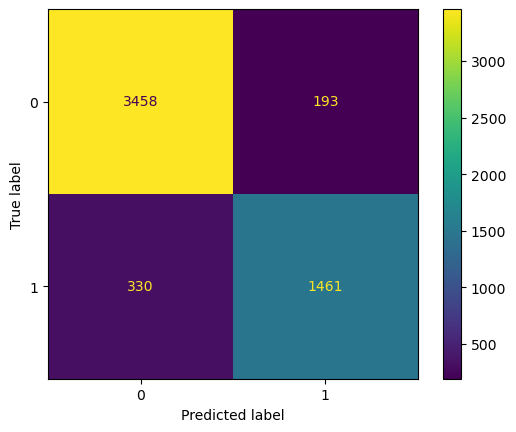

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_model.predict(X_test_processed))

**ROC Curve:**
The ROC curve illustrates the trade-off between the true positive rate and the false positive rate across different decision thresholds, while the AUC summarizes how well the model can distinguish between the two classes.

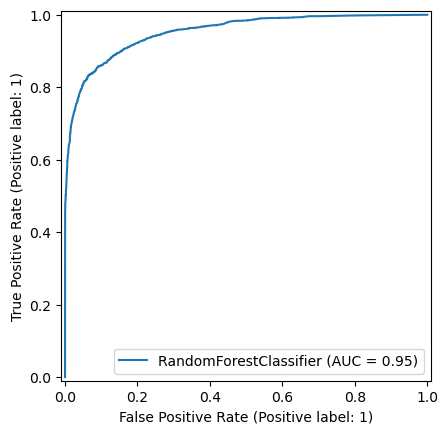

In [16]:
RocCurveDisplay.from_estimator(rf_model, X_test_processed, y_test)

**Feature importance**

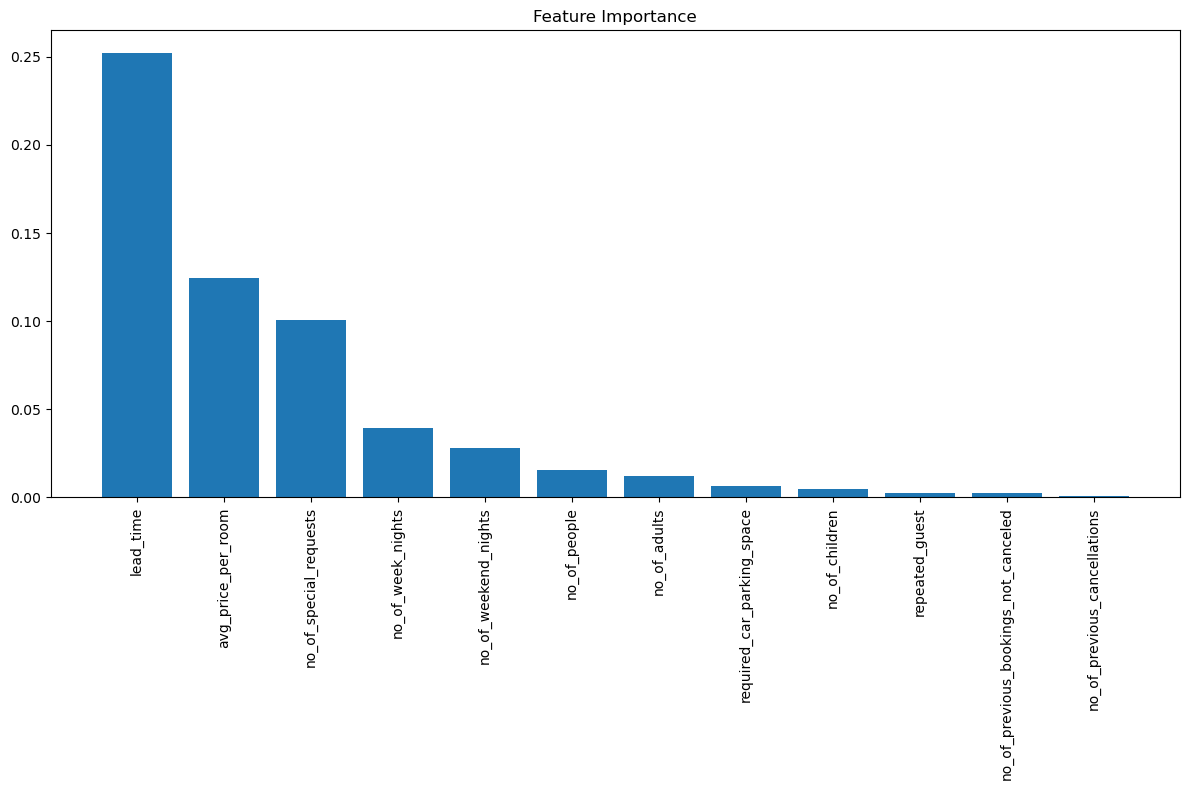

In [22]:
import matplotlib.pyplot as plt
import numpy as np


feature_mask = [
    'no_of_adults',
    'no_of_children',
    'no_of_weekend_nights',
    'no_of_week_nights',
    'required_car_parking_space',
    'lead_time',
    'repeated_guest',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_special_requests',
    'no_of_people'
]

# Feature importance from trained model
importances = rf_model.feature_importances_

# We only match the filtered features
importances_filtered = [importances[i] for i, col in enumerate(X_train_val.columns) if col in feature_mask]

indices = np.argsort(importances_filtered)[::-1]

plt.figure(figsize=(12,8))
plt.title("Feature Importance")
plt.bar(range(len(importances_filtered)), np.array(importances_filtered)[indices], align='center')
plt.xticks(range(len(importances_filtered)), [feature_mask[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()